#**LAB06 - Transformers aplicados a clasificación de residuos sólidos**

###**ESTUDIANTE : Cervantes Torres Atzel Alan  -  CICO**

## Objetivo general
Aplicar un modelo tipo Transformer (Vision Transformer - ViT) para la clasificación de imágenes de residuos sólidos, utilizando un dataset con 5 clases y aproximadamente 10,000 imágenes por clase.

## **1. Configuración del entorno**

En esta sección se monta Google Drive para acceder al dataset, y se instalan las librerías necesarias:
- **PyTorch** con soporte CUDA.
- **Torchvision** para transformaciones e integración con datasets.
- **scikit-learn** para particiones estratificadas y métricas.
- **seaborn** y **matplotlib** para visualizaciones.
- **tqdm** para barras de progreso.


In [ ]:
#@title Montaje de Drive e instalacion minima
from google.colab import drive
drive.mount('/content/drive')

!pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip -q install lightning==2.4.0
!pip -q install tqdm scikit-learn


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 59.1 MB/s eta 0:00:00


## **2. Preparación del dataset**

El dataset original se encuentra en Google Drive en la carpeta `ResiduosSolidosData/`.  
Cada subcarpeta representa una clase (ejemplo: tapas, colillas, mascarillas, etc.).  

Para acelerar el entrenamiento:
- Se copia el dataset al almacenamiento local de Colab.
- Se utiliza una barra de progreso para monitorear la copia.
- Se realiza una verificación rápida del número de imágenes por clase.


In [ ]:
#@title copy dataset to local with progress bars
import os, shutil, concurrent.futures
from pathlib import Path
from tqdm.auto import tqdm

srcDir = Path("/content/drive/MyDrive/ResiduosSolidosData")
dstDir = Path("/content/datasets/residuos")
dstDir.mkdir(parents=True, exist_ok=True)

def listFiles(root):
    pairs = []
    classes = []
    for cls in sorted([p for p in root.iterdir() if p.is_dir()]):
        classes.append(cls.name)
        for f in cls.rglob("*"):
            if f.is_file():
                rel = f.relative_to(root)
                pairs.append((f, dstDir/rel))
    return classes, pairs

classes, filePairs = listFiles(srcDir)

toCopy = []
for s,d in filePairs:
    d.parent.mkdir(parents=True, exist_ok=True)
    if not d.exists():
        toCopy.append((s,d))

pbar = tqdm(total=len(toCopy), desc="copying files", ncols=0)
def _copy(pair):
    s,d = pair
    shutil.copy2(s, d)
    return 1

workers = min(8, os.cpu_count() or 2)
with concurrent.futures.ThreadPoolExecutor(max_workers=workers) as ex:
    for _ in ex.map(_copy, toCopy):
        pbar.update(1)
pbar.close()

print("classes:", classes)


copying files:   0% 0/54340 [00:00<?, ?it/s]

classes: ['barbijos', 'boligrafos', 'cds_dvds', 'restos_cigarros', 'tapas_botella']


In [ ]:
#@title count per class with progress
import os
from collections import defaultdict
from tqdm.auto import tqdm

counts = defaultdict(int)
for cls in classes:
    cdir = dstDir/cls
    for _ in tqdm(list(cdir.rglob("*")), desc=f"scan {cls}", ncols=0):
        pass
    counts[cls] = sum(1 for f in cdir.rglob("*") if f.is_file())

counts


scan barbijos:   0% 0/10049 [00:00<?, ?it/s]

scan boligrafos:   0% 0/11930 [00:00<?, ?it/s]

scan cds_dvds:   0% 0/10028 [00:00<?, ?it/s]

scan restos_cigarros:   0% 0/12066 [00:00<?, ?it/s]

scan tapas_botella:   0% 0/10267 [00:00<?, ?it/s]

defaultdict(int,
            {'barbijos': 10049,
             'boligrafos': 11930,
             'cds_dvds': 10028,
             'restos_cigarros': 12066,
             'tapas_botella': 10267})

4) dataloaders (local path) con split estratificado

## **3. Transformaciones y DataLoaders**

Se aplican transformaciones de datos para robustecer el modelo y reducir el sobreajuste:

- **Entrenamiento**:
  - `RandomResizedCrop`
  - `RandomHorizontalFlip`
  - `ColorJitter`
  - Normalización con medias y desviaciones de ImageNet.

- **Validación y prueba**:
  - `Resize`
  - `CenterCrop`
  - Normalización con los mismos parámetros.

El dataset se divide de forma estratificada en tres subconjuntos:
- 70% entrenamiento
- 15% validación
- 15% prueba

Finalmente, se construyen `DataLoader` para cada subconjunto.


In [ ]:
#@title dataloaders
import numpy as np
import torch
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset, DataLoader

imgSize = 224
batchSize = 64
numWorkers = 4
seed = 42
g = torch.Generator().manual_seed(seed)

trainTfms = transforms.Compose([
    transforms.RandomResizedCrop(imgSize, scale=(0.7,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

valTfms = transforms.Compose([
    transforms.Resize(int(imgSize*1.15)),
    transforms.CenterCrop(imgSize),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

dataset = datasets.ImageFolder(root=str(dstDir))
targets = [y for _, y in dataset.samples]

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
trainIdx, testIdx = next(sss1.split(np.zeros(len(targets)), targets))
trainTargets = [targets[i] for i in trainIdx]

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
trainIdx2, valIdx = next(sss2.split(np.zeros(len(trainTargets)), trainTargets))
trainIdx = [trainIdx[i] for i in trainIdx2]

trainSet = Subset(dataset, trainIdx)
valSet = Subset(dataset, valIdx)
testSet = Subset(dataset, testIdx)

trainSet.dataset.transform = trainTfms
valSet.dataset.transform = valTfms
testSet.dataset.transform = valTfms

numClasses = len(dataset.classes)

trainLoader = DataLoader(trainSet, batch_size=batchSize, shuffle=True, num_workers=numWorkers, pin_memory=True, generator=g)
valLoader = DataLoader(valSet, batch_size=batchSize, shuffle=False, num_workers=numWorkers, pin_memory=True)
testLoader = DataLoader(testSet, batch_size=batchSize, shuffle=False, num_workers=numWorkers, pin_memory=True)

dataset.classes, len(trainSet), len(valSet), len(testSet)


(['barbijos', 'boligrafos', 'cds_dvds', 'restos_cigarros', 'tapas_botella'],
 39260,
 6929,
 8151)

5) modelo transformer vit-like minimal

## **4. Arquitectura del modelo Transformer**

Se implementa un modelo inspirado en Vision Transformer (ViT):

- **Patch Embedding**: cada imagen se divide en parches de 16x16 píxeles que se proyectan a un espacio de embedding.
- **Token [CLS]**: se añade un token especial para la clasificación.
- **Positional Encoding**: se suman embeddings posicionales aprendibles.
- **Transformer Encoder**: compuesto por capas con multi-head self-attention y feed-forward.
- **Head de clasificación**: capa lineal que predice la clase.

La arquitectura se construye de forma modular para permitir modificaciones futuras.


In [ ]:
#@title vit-like model
import math, torch, torch.nn as nn

class PatchEmbed(nn.Module):
    def __init__(self, imgSize=224, patchSize=16, inChans=3, embedDim=384):
        super().__init__()
        self.imgSize = imgSize
        self.patchSize = patchSize
        self.gridSize = imgSize // patchSize
        self.numPatches = self.gridSize * self.gridSize
        self.proj = nn.Conv2d(inChans, embedDim, kernel_size=patchSize, stride=patchSize)
    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1,2)
        return x

class ViTClassifier(nn.Module):
    def __init__(self, imgSize=224, patchSize=16, numClasses=5, dModel=384, nHeads=6, depth=8, mlpRatio=4.0, pDrop=0.1):
        super().__init__()
        self.patchEmbed = PatchEmbed(imgSize=imgSize, patchSize=patchSize, inChans=3, embedDim=dModel)
        numPatches = self.patchEmbed.numPatches
        self.clsToken = nn.Parameter(torch.zeros(1,1,dModel))
        self.posEmbed = nn.Parameter(torch.zeros(1,1+numPatches,dModel))
        enc = nn.TransformerEncoderLayer(d_model=dModel, nhead=nHeads, dim_feedforward=int(dModel*mlpRatio), dropout=pDrop, batch_first=True, activation="gelu", norm_first=True)
        self.encoder = nn.TransformerEncoder(enc, num_layers=depth)
        self.norm = nn.LayerNorm(dModel)
        self.head = nn.Linear(dModel, numClasses)
        nn.init.trunc_normal_(self.posEmbed, std=0.02)
        nn.init.trunc_normal_(self.clsToken, std=0.02)
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)
    def forward(self, x):
        x = self.patchEmbed(x)
        b = x.shape[0]
        cls = self.clsToken.expand(b,-1,-1)
        x = torch.cat((cls,x), dim=1)
        x = x + self.posEmbed[:, : x.size(1), :]
        x = self.encoder(x)
        x = self.norm(x[:,0])
        x = self.head(x)
        return x

device = "cuda" if torch.cuda.is_available() else "cpu"
model = ViTClassifier(imgSize=imgSize, patchSize=16, numClasses=numClasses, dModel=384, nHeads=6, depth=8, mlpRatio=4.0, pDrop=0.1).to(device)
sum(p.numel() for p in model.parameters())/1e6


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


14.569733

6) optimizador, scheduler y entrenamiento con barras

## **5. Entrenamiento del modelo**

Se utiliza un bucle de entrenamiento que incluye:

- **Optimizador**: AdamW con `weight decay` para evitar sobreajuste.
- **Scheduler**: Warmup + Cosine Annealing para ajustar dinámicamente la tasa de aprendizaje.
- **Loss**: CrossEntropy con *label smoothing*.
- **Mixed Precision Training**: para acelerar el entrenamiento en GPU y optimizar memoria.
- **Early Stopping**: para detener el entrenamiento si la pérdida de validación no mejora después de varias épocas.

Durante el entrenamiento se muestran barras de progreso con `tqdm` y métricas en cada época.


In [ ]:
#@title rebuild dataloaders with spawn + persistent_workers
import torch, torch.multiprocessing as mp
from torch.utils.data import Subset, DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

try:
    mp.set_start_method("spawn", force=True)
except RuntimeError:
    pass

imgSize = 224
batchSize = 64
seed = 42
g = torch.Generator().manual_seed(seed)

trainTfms = transforms.Compose([
    transforms.RandomResizedCrop(imgSize, scale=(0.7,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

valTfms = transforms.Compose([
    transforms.Resize(int(imgSize*1.15)),
    transforms.CenterCrop(imgSize),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

dataset = datasets.ImageFolder(root="/content/datasets/residuos")
targets = [y for _, y in dataset.samples]

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
trainIdx, testIdx = next(sss1.split(np.zeros(len(targets)), targets))
trainTargets = [targets[i] for i in trainIdx]

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=seed)
trainIdx2, valIdx = next(sss2.split(np.zeros(len(trainTargets)), trainTargets))
trainIdx = [trainIdx[i] for i in trainIdx2]

trainSet = Subset(dataset, trainIdx)
valSet = Subset(dataset, valIdx)
testSet = Subset(dataset, testIdx)

trainSet.dataset.transform = trainTfms
valSet.dataset.transform = valTfms
testSet.dataset.transform = valTfms

hasCuda = torch.cuda.is_available()
pinMem = True if hasCuda else False
numWorkers = 2

trainLoader = DataLoader(
    trainSet, batch_size=batchSize, shuffle=True,
    num_workers=numWorkers, pin_memory=pinMem, generator=g,
    persistent_workers=True, prefetch_factor=2, multiprocessing_context="spawn"
)

valLoader = DataLoader(
    valSet, batch_size=batchSize, shuffle=False,
    num_workers=numWorkers, pin_memory=pinMem,
    persistent_workers=True, prefetch_factor=2, multiprocessing_context="spawn"
)

testLoader = DataLoader(
    testSet, batch_size=batchSize, shuffle=False,
    num_workers=numWorkers, pin_memory=pinMem,
    persistent_workers=True, prefetch_factor=2, multiprocessing_context="spawn"
)

dataset.classes, len(trainSet), len(valSet), len(testSet)


(['barbijos', 'boligrafos', 'cds_dvds', 'restos_cigarros', 'tapas_botella'],
 39260,
 6929,
 8151)

In [ ]:
#@title train loop with progress bars (cuda-safe, amp api nueva)
import math, os, torch, torch.nn as nn, torch.nn.functional as F
from tqdm.auto import tqdm

hasCuda = torch.cuda.is_available()
device = "cuda" if hasCuda else "cpu"

lr = 3e-4
weightDecay = 1e-4
numEpochs = 20
warmupEpochs = 2
patience = 5
useMixedPrecision = hasCuda

class WarmupCosine:
    def __init__(self, optimizer, warmupEpochs, maxEpochs, baseLr):
        self.optimizer = optimizer
        self.warmupEpochs = warmupEpochs
        self.maxEpochs = maxEpochs
        self.baseLr = baseLr
        self.epoch = 0
    def step(self):
        self.epoch += 1
    def getLr(self):
        if self.epoch <= self.warmupEpochs:
            return self.baseLr * self.epoch / max(1,self.warmupEpochs)
        t = (self.epoch - self.warmupEpochs) / max(1,(self.maxEpochs - self.warmupEpochs))
        return 0.5 * self.baseLr * (1 + math.cos(math.pi * t))
    def setLr(self, lr):
        for g in self.optimizer.param_groups:
            g["lr"] = lr

class EarlyStopper:
    def __init__(self, patience=5):
        self.patience = patience
        self.best = None
        self.bad = 0
    def step(self, metric):
        if self.best is None or metric < self.best:
            self.best = metric
            self.bad = 0
            return True
        self.bad += 1
        return False
    def shouldStop(self):
        return self.bad >= self.patience

class Avg:
    def __init__(self):
        self.s=0.0; self.c=0
    def upd(self,v,n=1):
        self.s+=v*n; self.c+=n
    @property
    def avg(self):
        return self.s/max(1,self.c)

def accTop1(logits, y):
    return (logits.argmax(1)==y).float().mean().item()

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weightDecay)
sched = WarmupCosine(optimizer, warmupEpochs=warmupEpochs, maxEpochs=numEpochs, baseLr=lr)
early = EarlyStopper(patience=patience)

scaler = torch.amp.GradScaler("cuda") if hasCuda and useMixedPrecision else None
autocast_ctx = lambda: torch.amp.autocast("cuda", enabled=hasCuda and useMixedPrecision)

outDir = "/content/transformer_runs"
os.makedirs(outDir, exist_ok=True)
bestPath = os.path.join(outDir, "vit_residuos_best.pt")
history = {"epoch":[], "trainLoss":[], "trainAcc":[], "valLoss":[], "valAcc":[]}

if hasCuda:
    torch.backends.cudnn.benchmark = True

pinMem = True if hasCuda else False
trainLoader.pin_memory = pinMem
valLoader.pin_memory = pinMem
testLoader.pin_memory = pinMem

for epoch in range(1, numEpochs+1):
    model.train()
    trL, trA = Avg(), Avg()
    pbar = tqdm(trainLoader, desc=f"train {epoch}/{numEpochs}", ncols=0)
    optimizer.zero_grad(set_to_none=True)
    for x,y in pbar:
        x=x.to(device, non_blocking=hasCuda); y=y.to(device, non_blocking=hasCuda)
        with autocast_ctx():
            logits = model(x)
            loss = F.cross_entropy(logits, y, label_smoothing=0.05)
        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        trL.upd(loss.item(), x.size(0))
        trA.upd(accTop1(logits.detach(), y), x.size(0))
        pbar.set_postfix(loss=f"{trL.avg:.4f}", acc=f"{trA.avg:.4f}")
    sched.step(); sched.setLr(sched.getLr())

    model.eval()
    vaL, vaA = Avg(), Avg()
    with torch.no_grad():
        for x,y in tqdm(valLoader, desc="val", ncols=0):
            x=x.to(device, non_blocking=hasCuda); y=y.to(device, non_blocking=hasCuda)
            with autocast_ctx():
                logits = model(x)
                loss = F.cross_entropy(logits, y)
            vaL.upd(loss.item(), x.size(0))
            vaA.upd(accTop1(logits, y), x.size(0))

    history["epoch"].append(epoch)
    history["trainLoss"].append(trL.avg)
    history["trainAcc"].append(trA.avg)
    history["valLoss"].append(vaL.avg)
    history["valAcc"].append(vaA.avg)

    improved = early.step(vaL.avg)
    if improved:
        torch.save({"model":model.state_dict(),"classes":dataset.classes,"imgSize":imgSize}, bestPath)
    if early.shouldStop():
        break

history


train 1/20:   0% 0/614 [00:05<?, ?it/s]

val:   0% 0/109 [00:05<?, ?it/s]

train 2/20:   0% 0/614 [00:00<?, ?it/s]

val:   0% 0/109 [00:00<?, ?it/s]

train 3/20:   0% 0/614 [00:00<?, ?it/s]

...

train 6/20:   0% 0/614 [00:00<?, ?it/s]

val:   0% 0/109 [00:00<?, ?it/s]

train 7/20:   0% 0/614 [00:00<?, ?it/s]

val:   0% 0/109 [00:00<?, ?it/s]

{'epoch': [1, 2, 3, 4, 5, 6, 7],
 'trainLoss': [0.2828196166640207,
  0.24823985170237095,
  0.28888510431006925,
  0.2781906340144085,
  0.2752557345482384,
  0.26820053974706426,
  0.26050192705539194],
 'trainAcc': [0.9765155374426897,
  0.9898624554253693,
  0.9739174732673672,
  0.9781202241588598,
  0.9795720835455934,
  0.9818899643524411,
  0.9852521650656352],
 'valLoss': [0.09024725896762656,
  0.06389764694101557,
  0.09542212896731822,
  0.07644555324424843,
  0.08637983091621795,
  0.10461616708479982,
  0.07812244329009588],
 'valAcc': [0.98080531101169,
  0.9909077789002743,
  0.9800837061625054,
  0.9857122239861452,
  0.9832587674989176,
  0.9771972867657671,
  0.9867224707750036]}

## **6. Curvas de entrenamiento**

Se grafican las curvas de:
- Pérdida de entrenamiento vs validación.
- Exactitud de entrenamiento vs validación.

Esto permite observar la convergencia del modelo y posibles signos de sobreajuste.


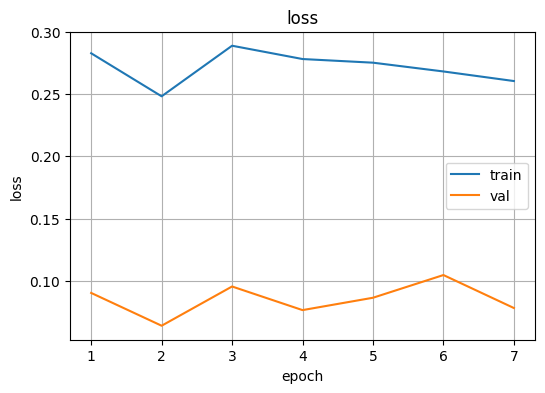

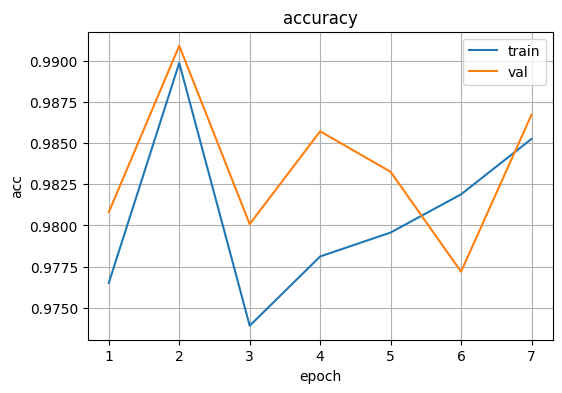

In [ ]:
#@title training curves
import matplotlib.pyplot as plt
ep = history["epoch"]
plt.figure(figsize=(6,4))
plt.plot(ep, history["trainLoss"], label="train")
plt.plot(ep, history["valLoss"], label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("loss"); plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(ep, history["trainAcc"], label="train")
plt.plot(ep, history["valAcc"], label="val")
plt.xlabel("epoch"); plt.ylabel("acc"); plt.title("accuracy"); plt.grid(True); plt.legend(); plt.show()


## **7. Evaluación final en el conjunto de prueba**

Se cargan los pesos del mejor modelo (guardados con `torch.save`) y se evalúa el desempeño en el conjunto de prueba:

- Reporte de clasificación (precisión, recall, F1-score por clase).
- Matriz de confusión con valores absolutos.
- Matriz de confusión normalizada para análisis relativo.

Esto permite identificar las clases con mayor confusión y medir el rendimiento global.


test:   0% 0/128 [00:00<?, ?it/s]

                 precision    recall  f1-score   support

       barbijos     0.9581    0.9861    0.9719      1507
     boligrafos     0.9909    0.9732    0.9820      1790
       cds_dvds     0.9881    0.9914    0.9897      1504
restos_cigarros     0.9861    0.9790    0.9825      1810
  tapas_botella     0.9883    0.9857    0.9870      1540

       accuracy                         0.9826      8151
      macro avg     0.9823    0.9831    0.9826      8151
   weighted avg     0.9827    0.9826    0.9826      8151



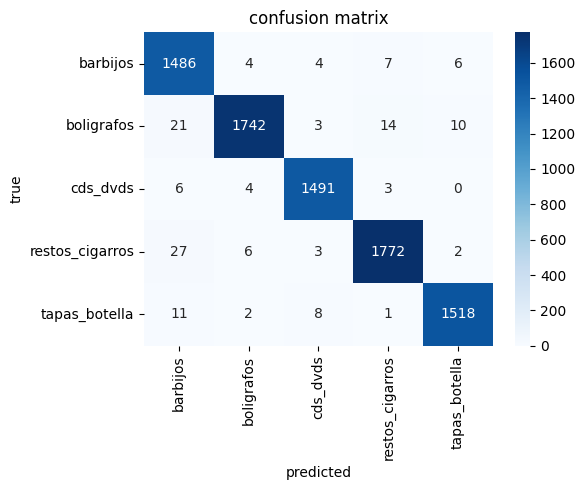

In [ ]:
#@title evaluacion final en test con matriz de confusion
import torch, numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# cargar mejor checkpoint
ckpt = torch.load(bestPath, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

allY, allP = [], []
for x,y in tqdm(testLoader, desc="test", ncols=0):
    x = x.to(device, non_blocking=torch.cuda.is_available())
    with torch.no_grad():
        logits = model(x)
    pred = logits.argmax(1).cpu().numpy()
    allP.extend(pred.tolist())
    allY.extend(y.numpy().tolist())

# reporte completo por clase
print(classification_report(allY, allP, target_names=dataset.classes, digits=4))

# matriz de confusion
cm = confusion_matrix(allY, allP)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel("predicted")
plt.ylabel("true")
plt.title("confusion matrix")
plt.tight_layout()
plt.show()


             clase  imagenes  aciertos  accuracy_pct
0         barbijos      1507      1486         98.61
1       boligrafos      1790      1742         97.32
2         cds_dvds      1504      1491         99.14
3  restos_cigarros      1810      1772         97.90
4    tapas_botella      1540      1518         98.57


/tmp/ipython-input-3812352832.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dfAcc, x="clase", y="accuracy_pct", palette="crest")


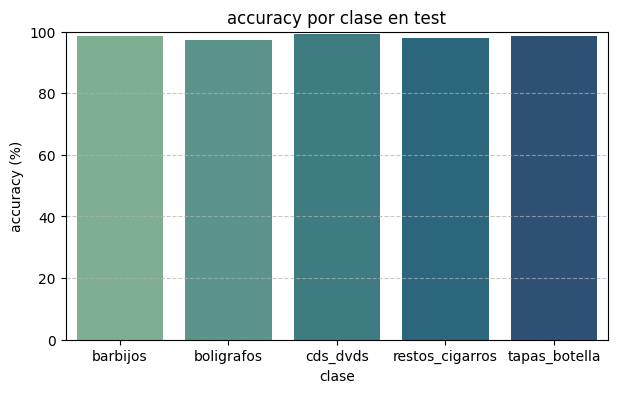

In [ ]:
#@title tabla de aciertos por clase
import pandas as pd

cm = confusion_matrix(allY, allP)
accPerClass = cm.diagonal() / cm.sum(axis=1)  # diag / total por clase

dfAcc = pd.DataFrame({
    "clase": dataset.classes,
    "imagenes": cm.sum(axis=1),
    "aciertos": cm.diagonal(),
    "accuracy_pct": (accPerClass*100).round(2)
})

print(dfAcc)

# grafico de barras para visualizar
plt.figure(figsize=(7,4))
sns.barplot(data=dfAcc, x="clase", y="accuracy_pct", palette="crest")
plt.ylabel("accuracy (%)")
plt.title("accuracy por clase en test")
plt.ylim(0,100)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In [ ]:
#@title single image prediction
from PIL import Image
inferTfms = transforms.Compose([
    transforms.Resize(int(imgSize*1.15)),
    transforms.CenterCrop(imgSize),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

def predictImage(path):
    img = Image.open(path).convert("RGB")
    x = inferTfms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[0].cpu().numpy()
    i = int(np.argmax(prob))
    return dataset.classes[i], float(prob[i])

# example:
# predictImage("/content/datasets/residuos/tapas_botella/xxxx.jpg")


## **8. Guardado del mejor modelo**

El mejor modelo entrenado se guarda en Google Drive en formato `.pt` para poder reutilizarlo en sesiones posteriores o para despliegue.

Ruta de guardado:  
`/content/drive/MyDrive/ModelosResiduos/vit_residuos_best.pt`


In [ ]:
#@title guardar mejor modelo en drive
import shutil, os

# ruta donde se guardo el mejor modelo en el entrenamiento
bestPath = "/content/transformer_runs/vit_residuos_best.pt"

# carpeta destino en tu drive
driveDir = "/content/drive/MyDrive/ModelosResiduos"
os.makedirs(driveDir, exist_ok=True)

dstPath = os.path.join(driveDir, "vit_residuos_best.pt")
shutil.copy2(bestPath, dstPath)

print("modelo guardado en:", dstPath)


modelo guardado en: /content/drive/MyDrive/ModelosResiduos/vit_residuos_best.pt


## **9. Predicción individual sobre imágenes externas**

Se implementan funciones de inferencia que permiten:

- Cargar imágenes desde una **URL**.
- Cargar imágenes desde una **ruta en Drive o local**.
- Subir imágenes manualmente con `files.upload()`.

El resultado incluye:
- La imagen original.
- La clase predicha con su probabilidad.
- Un gráfico de barras con la distribución de probabilidades en todas las clases (confusión relativa).


In [ ]:
#@title load and predict: drive + model + url/path/upload
import os, io, torch, numpy as np, requests
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from google.colab import drive, files
from torchvision import transforms
import torch.nn as nn

drive.mount('/content/drive')

ckptPath = "/content/drive/MyDrive/ModelosResiduos/vit_residuos_best.pt"

class PatchEmbed(nn.Module):
    def __init__(self, imgSize=224, patchSize=16, inChans=3, embedDim=384):
        super().__init__()
        self.imgSize = imgSize
        self.patchSize = patchSize
        self.gridSize = imgSize // patchSize
        self.numPatches = self.gridSize * self.gridSize
        self.proj = nn.Conv2d(inChans, embedDim, kernel_size=patchSize, stride=patchSize)
    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1,2)
        return x

class ViTClassifier(nn.Module):
    def __init__(self, imgSize=224, patchSize=16, numClasses=5, dModel=384, nHeads=6, depth=8, mlpRatio=4.0, pDrop=0.1):
        super().__init__()
        self.patchEmbed = PatchEmbed(imgSize=imgSize, patchSize=patchSize, inChans=3, embedDim=dModel)
        numPatches = self.patchEmbed.numPatches
        self.clsToken = nn.Parameter(torch.zeros(1,1,dModel))
        self.posEmbed = nn.Parameter(torch.zeros(1,1+numPatches,dModel))
        enc = nn.TransformerEncoderLayer(d_model=dModel, nhead=nHeads, dim_feedforward=int(dModel*mlpRatio), dropout=pDrop, batch_first=True, activation="gelu", norm_first=True)
        self.encoder = nn.TransformerEncoder(enc, num_layers=depth)
        self.norm = nn.LayerNorm(dModel)
        self.head = nn.Linear(dModel, numClasses)
        nn.init.trunc_normal_(self.posEmbed, std=0.02)
        nn.init.trunc_normal_(self.clsToken, std=0.02)
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)
    def forward(self, x):
        x = self.patchEmbed(x)
        b = x.shape[0]
        cls = self.clsToken.expand(b,-1,-1)
        x = torch.cat((cls,x), dim=1)
        x = x + self.posEmbed[:, : x.size(1), :]
        x = self.encoder(x)
        x = self.norm(x[:,0])
        x = self.head(x)
        return x

device = "cuda" if torch.cuda.is_available() else "cpu"
ckpt = torch.load(ckptPath, map_location=device)
classes = ckpt["classes"]
imgSize = int(ckpt.get("imgSize", 224))

model = ViTClassifier(imgSize=imgSize, patchSize=16, numClasses=len(classes), dModel=384, nHeads=6, depth=8, mlpRatio=4.0, pDrop=0.1).to(device)
model.load_state_dict(ckpt["model"])
model.eval()

inferTfms = transforms.Compose([
    transforms.Resize(int(imgSize*1.15)),
    transforms.CenterCrop(imgSize),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

def loadPilFromPath(path):
    img = Image.open(path).convert("RGB")
    return img

def loadPilFromUrl(url):
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    img = Image.open(io.BytesIO(r.content)).convert("RGB")
    return img

def predictPil(img, topk=5):
    x = inferTfms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[0].cpu().numpy()
    idx = int(np.argmax(prob))
    topIdx = np.argsort(prob)[::-1][:topk]
    top = [(classes[i], float(prob[i])) for i in topIdx]
    return idx, prob, top

def showResult(img, idx, prob):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"pred: {classes[idx]} ({prob[idx]*100:.2f}%)")
    plt.subplot(1,2,2)
    df = pd.DataFrame({"class": classes, "prob": prob})
    df = df.sort_values("prob", ascending=True)
    plt.barh(df["class"], df["prob"]*100)
    plt.xlabel("probability (%)")
    plt.title("confusion vs other classes")
    plt.tight_layout()
    plt.show()

def predictFromPath(path):
    img = loadPilFromPath(path)
    idx, prob, top = predictPil(img)
    showResult(img, idx, prob)
    return classes[idx], float(prob[idx]), [(c, float(p)) for c,p in top]

def predictFromUrl(url):
    img = loadPilFromUrl(url)
    idx, prob, top = predictPil(img)
    showResult(img, idx, prob)
    return classes[idx], float(prob[idx]), [(c, float(p)) for c,p in top]

def predictFromUpload():
    up = files.upload()
    out = {}
    for name in up.keys():
        pred, p, top = predictFromPath(name)
        out[name] = {"pred": pred, "prob": p, "top": top}
    return out

print("ready:", device, "| classes:", classes)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ready: cuda | classes: ['barbijos', 'boligrafos', 'cds_dvds', 'restos_cigarros', 'tapas_botella']


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


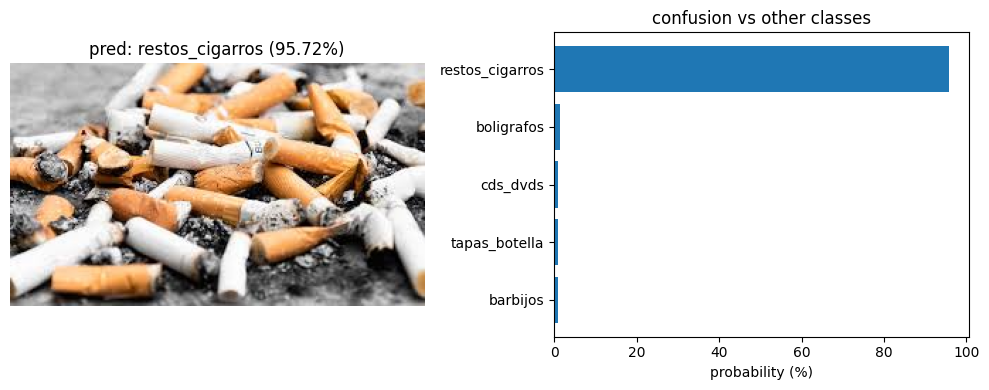

restos_cigarros 0.9572 [('restos_cigarros', 0.9571986794471741), ('boligrafos', 0.01325264573097229), ('cds_dvds', 0.009919684380292892), ('tapas_botella', 0.009847925044596195), ('barbijos', 0.009781071916222572)]


In [ ]:
pred, prob, top = predictFromUrl("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR1vDUK6tY_CSBBOTt_2gV12BAr9sxk1xGc-w&s")
print(pred, round(prob,4), top)


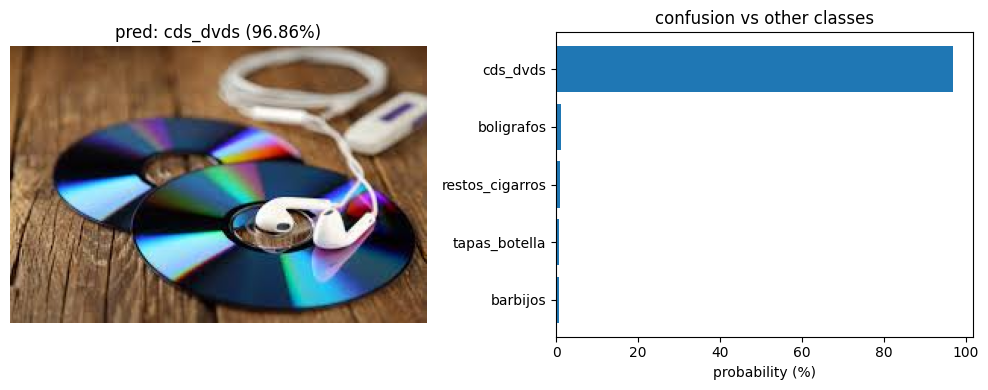

cds_dvds 0.9686 [('cds_dvds', 0.9686046242713928), ('boligrafos', 0.010706822387874126), ('restos_cigarros', 0.008307169191539288), ('tapas_botella', 0.006220296490937471), ('barbijos', 0.006161115597933531)]


In [ ]:
pred, prob, top = predictFromUrl("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRwcbcbqSOc-X0lltfjkdMtC8uJRUz57Q4a2A&s")
print(pred, round(prob,4), top)


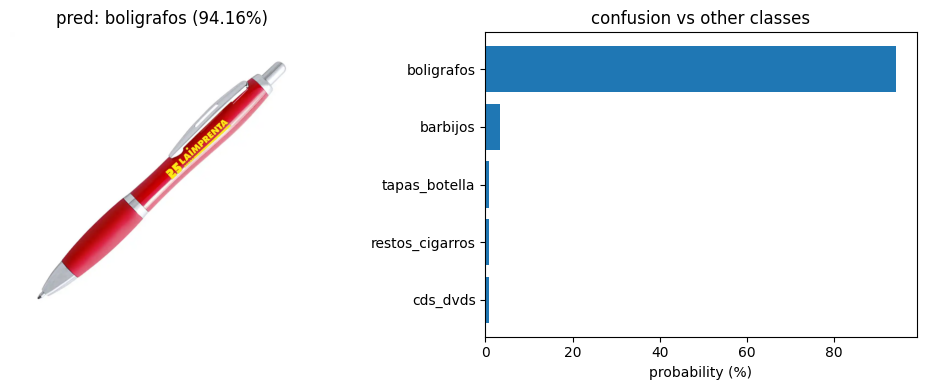

boligrafos 0.9416 [('boligrafos', 0.941611111164093), ('barbijos', 0.033792171627283096), ('tapas_botella', 0.009103936143219471), ('restos_cigarros', 0.008095393888652325), ('cds_dvds', 0.007397443521767855)]


In [ ]:
pred, prob, top = predictFromUrl("https://cdn.laimprentacg.com/compra2/pro/products/116/2023/4/18/boligrafos-plastico-2301-003p-fucsia.jpeg")
print(pred, round(prob,4), top)


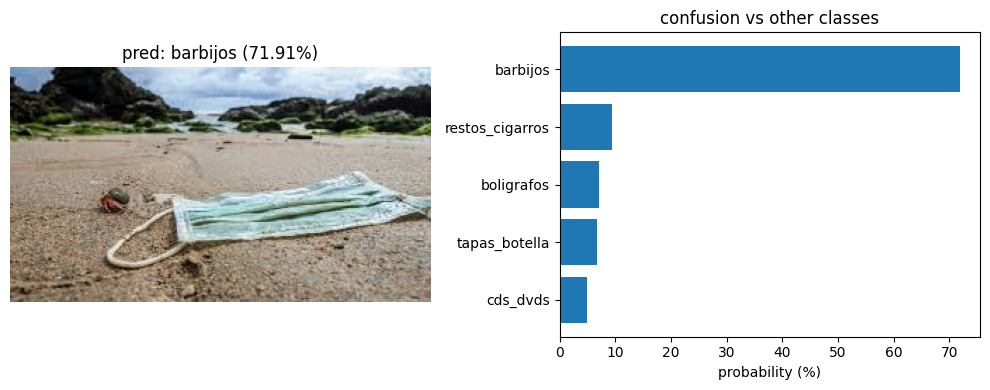

barbijos 0.7191 [('barbijos', 0.7190964818000793), ('restos_cigarros', 0.09396860003471375), ('boligrafos', 0.07114149630069733), ('tapas_botella', 0.06619887799024582), ('cds_dvds', 0.04959454387426376)]


In [ ]:
pred, prob, top = predictFromUrl("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQitfAjbgrRyvV93GwHUZfw-W_1gNl0NXJiAw&s")
print(pred, round(prob,4), top)


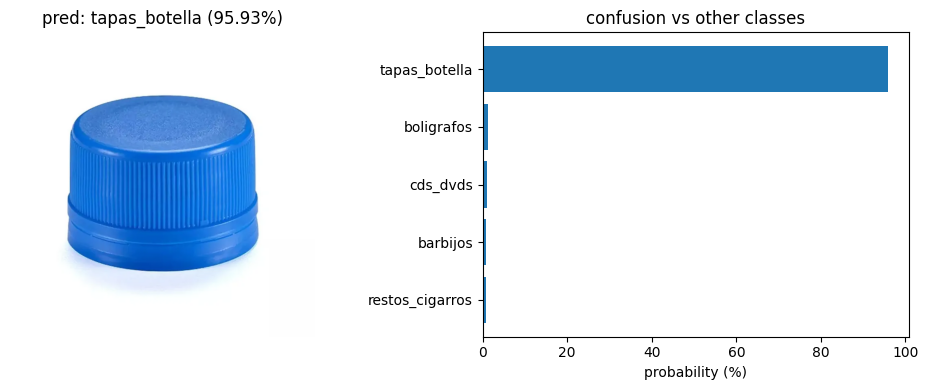

tapas_botella 0.9593 [('tapas_botella', 0.9593395590782166), ('boligrafos', 0.012834308668971062), ('cds_dvds', 0.01123617310076952), ('barbijos', 0.00904963817447424), ('restos_cigarros', 0.007540326099842787)]


In [ ]:
pred, prob, top = predictFromUrl("https://image.made-in-china.com/365f3j00nSeomfPYLTkF/Tapa-de-botella-de-pl-stico-blanca-y-azul-de-alta-calidad-Pco-1810-1881-Precio-est-ndar-internacional.webp")
print(pred, round(prob,4), top)


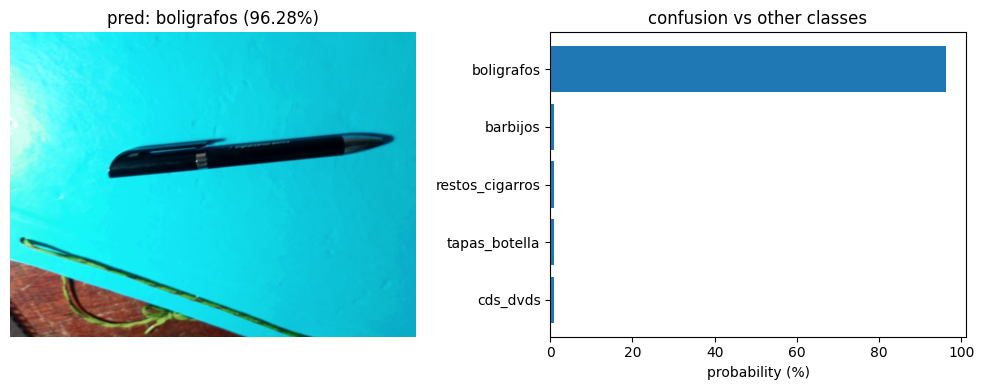

boligrafos 0.9628 [('boligrafos', 0.9628089666366577), ('barbijos', 0.009937616065144539), ('restos_cigarros', 0.009927661158144474), ('tapas_botella', 0.008828556165099144), ('cds_dvds', 0.00849724467843771)]


In [ ]:
pred, prob, top = predictFromPath("/content/drive/MyDrive/ResiduosSolidosData/boligrafos/000028.jpg")
print(pred, round(prob,4), top)
